# EvolveGCN-H 500U Top500 vs 750U Top1000 Results

This notebook analyzes the controlled comparison between two no-normalization EvolveGCN-H experiments:

1. `EvolveGCN-H 500U Top500 none`
2. `EvolveGCN-H 750U Top1000 none`

The goal is to summarize whether increasing both the number of CAMELS-SIMBA universes and the number of selected halos improves `Omega_m` prediction, and whether that improvement is enough to resolve the remaining graph-model underperformance.

This notebook is analysis-only. It reads existing result CSV files and writes derived tables and figures to `outputs/evolvegcn_500u_vs_750u_results/`. It does not modify raw data, processed data, experiment folders, trained models, or source code.

## Research snapshot status

This notebook preserves the dated five-seed 500U Top500 versus 750U Top1000 comparison represented by its saved summary CSV files. The displayed values are research-snapshot evidence, not final thesis results. Final tables will be regenerated from verified experiment artifacts.

## 1. Research Question

This comparison addresses three questions:

1. Does moving from `500U Top500` to `750U Top1000` improve EvolveGCN-H test performance?
2. Are the improvements consistent across test MAE, test RMSE, and test R²?
3. Does the larger dataset and larger halo graph solve the remaining prediction-collapse or underperformance issue?

## 2. Experiment Scope

Both experiments use EvolveGCN-H with no per-snapshot feature normalization. The comparison is based on five random seeds for each setting. The seed-level input table contains one row per run, while the group-level summary table aggregates performance across seeds.

The main metrics are:

- test MAE from saved predictions
- test RMSE from saved predictions
- test R² from saved predictions

Lower MAE and RMSE are better. Higher R² is better, but negative R² indicates that the model still explains target variance poorly relative to a simple mean baseline.

## 3. Setup and Paths

This setup cell finds the repository root, defines the two input CSV paths, creates the notebook-specific output folder, and sets compact display options for thesis-facing tables.

In [44]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path | None = None) -> Path:
    """Find repository root from either the repo root or notebooks/visualization."""
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "outputs").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Could not find repository root containing outputs/ and notebooks/.")


REPO_ROOT = find_repo_root()
INPUT_SEED_TABLE = REPO_ROOT / "outputs" / "evolvegcn_500top500_vs_750top1000_5seed_table.csv"
INPUT_GROUP_SUMMARY = REPO_ROOT / "outputs" / "evolvegcn_500top500_vs_750top1000_5seed_group_summary.csv"
OUT_DIR = REPO_ROOT / "outputs" / "evolvegcn_500u_vs_750u_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

print(f"Repository root:      {REPO_ROOT}")
print(f"Seed-level table:     {INPUT_SEED_TABLE}")
print(f"Group-level summary:  {INPUT_GROUP_SUMMARY}")
print(f"Output folder:        {OUT_DIR}")

Repository root:      <REPO_ROOT>
Seed-level table:     <REPO_ROOT>/outputs/evolvegcn_500top500_vs_750top1000_5seed_table.csv
Group-level summary:  <REPO_ROOT>/outputs/evolvegcn_500top500_vs_750top1000_5seed_group_summary.csv
Output folder:        <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results


## 4. Helper Functions

The helper functions standardize group names, load the existing summary if available, reconstruct summary statistics from the seed-level table, and format values for compact mean ± std display.

In [45]:
GROUP_LABELS = {
    "EvolveGCN_500U_Top500_none": "500U Top500",
    "EvolveGCN_750U_Top1000_none": "750U Top1000",
}

METRIC_COLUMNS = [
    "test_mae_from_predictions",
    "test_rmse_from_predictions",
    "test_r2_from_predictions",
]

METRIC_LABELS = {
    "test_mae_from_predictions": "Test MAE",
    "test_rmse_from_predictions": "Test RMSE",
    "test_r2_from_predictions": "Test R²",
}


def add_group_label(df: pd.DataFrame) -> pd.DataFrame:
    labeled = df.copy()
    labeled["setting"] = labeled["group"].map(GROUP_LABELS).fillna(labeled["group"])
    return labeled


def reconstruct_group_summary(seed_df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        seed_df.groupby("group", sort=False)[METRIC_COLUMNS]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    summary.columns = ["_".join(col).rstrip("_") if isinstance(col, tuple) else col for col in summary.columns]
    return add_group_label(summary)


def load_existing_group_summary(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        return None

    try:
        raw = pd.read_csv(path, header=[0, 1], index_col=0)
        raw = raw.dropna(how="all")
        raw = raw[raw.index.astype(str) != "group"]

        rows = []
        for group_name, row in raw.iterrows():
            result = {"group": group_name}
            for metric in METRIC_COLUMNS:
                for stat in ["mean", "std", "count"]:
                    result[f"{metric}_{stat}"] = row[(metric, stat)]
            rows.append(result)

        if rows:
            return add_group_label(pd.DataFrame(rows))
    except Exception as exc:
        print(f"Could not load group summary directly; will reconstruct from seed table. Reason: {exc}")

    return None


def format_mean_std(mean_value: float, std_value: float, digits: int = 4) -> str:
    return f"{mean_value:.{digits}f} ± {std_value:.{digits}f}"


def make_mean_std_table(summary_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in summary_df.iterrows():
        rows.append(
            {
                "Setting": row["setting"],
                "Seeds": int(row["test_rmse_from_predictions_count"]),
                "Test MAE": format_mean_std(
                    row["test_mae_from_predictions_mean"],
                    row["test_mae_from_predictions_std"],
                ),
                "Test RMSE": format_mean_std(
                    row["test_rmse_from_predictions_mean"],
                    row["test_rmse_from_predictions_std"],
                ),
                "Test R²": format_mean_std(
                    row["test_r2_from_predictions_mean"],
                    row["test_r2_from_predictions_std"],
                ),
            }
        )
    return pd.DataFrame(rows)


def save_metric_plot(summary_df: pd.DataFrame, metric: str, output_path: Path) -> None:
    labels = summary_df["setting"].to_numpy()
    means = summary_df[f"{metric}_mean"].astype(float).to_numpy()
    stds = summary_df[f"{metric}_std"].astype(float).to_numpy()

    fig, ax = plt.subplots(figsize=(5.0, 3.4))
    x = np.arange(len(labels))
    bars = ax.bar(x, means, yerr=stds, capsize=5, color=["#4C78A8", "#59A14F"], edgecolor="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.set_title(f"EvolveGCN-H Comparison: {METRIC_LABELS[metric]}")
    ax.grid(axis="y", alpha=0.25)

    for bar, value in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.4f}",
            ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=9,
        )

    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to: {output_path}")

## 5. Load Seed-Level Results

This section loads the five-seed result table and saves a clean thesis-facing copy with readable setting names and rounded metric columns.

In [46]:
seed_df = pd.read_csv(INPUT_SEED_TABLE)
seed_df = add_group_label(seed_df)

clean_seed_df = seed_df[
    [
        "setting",
        "seed",
        "experiment",
        "best_epoch",
        "best_val_mse",
        "trainable_parameters",
        "test_mae_from_predictions",
        "test_rmse_from_predictions",
        "test_r2_from_predictions",
    ]
].rename(
    columns={
        "setting": "Setting",
        "seed": "Seed",
        "experiment": "Experiment",
        "best_epoch": "Best Epoch",
        "best_val_mse": "Best Val MSE",
        "trainable_parameters": "Trainable Parameters",
        "test_mae_from_predictions": "Test MAE",
        "test_rmse_from_predictions": "Test RMSE",
        "test_r2_from_predictions": "Test R²",
    }
)

clean_seed_df = clean_seed_df.sort_values(["Setting", "Seed"]).reset_index(drop=True)
clean_seed_df.to_csv(OUT_DIR / "seed_level_results_clean.csv", index=False)

display(clean_seed_df)
print(f"Saved clean seed-level table to: {OUT_DIR / 'seed_level_results_clean.csv'}")

,Setting,Seed,Experiment,Best Epoch,Best Val MSE,Trainable Parameters,Test MAE,Test RMSE,Test R²
0,500U Top500,42,evolvegcn_h_500u_top500_h32_seed42_none_norm,40,0.004940,3409153,0.056713,0.066444,-1.692997
1,500U Top500,123,evolvegcn_h_500u_top500_h32_seed123_none,27,0.005697,3409153,0.063922,0.074663,-1.544970
2,500U Top500,777,evolvegcn_h_500u_top500_h32_seed777_none,74,0.003470,3409153,0.056338,0.066674,-1.507052
3,500U Top500,999,evolvegcn_h_500u_top500_h32_seed999_none,28,0.006316,3409153,0.063280,0.076409,-1.052795
4,500U Top500,2025,evolvegcn_h_500u_top500_h32_seed2025_none,163,0.004836,3409153,0.056536,0.067994,-1.299655
5,750U Top1000,42,evolvegcn_h_750u_top1000_h32_seed42_none,70,0.006180,3409153,0.056336,0.066091,-1.712632
6,750U Top1000,123,evolvegcn_h_750u_top1000_h32_seed123_none,60,0.002821,3409153,0.050190,0.062201,-1.050327
7,750U Top1000,777,evolvegcn_h_750u_top1000_h32_seed777_none,14,0.005475,3409153,0.060764,0.070803,-1.706109
8,750U Top1000,999,evolvegcn_h_750u_top1000_h32_seed999_none,45,0.003498,3409153,0.051804,0.065133,-0.824934
9,750U Top1000,2025,evolvegcn_h_750u_top1000_h32_seed2025_none,114,0.005852,3409153,0.058277,0.073326,-0.782514


Saved clean seed-level table to: <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results/seed_level_results_clean.csv


## 6. Mean ± Std Summary

This section loads the existing group-level summary when possible and reconstructs the same statistics from the seed-level table as a reproducibility check. The displayed table focuses on the three thesis-relevant test metrics.

In [47]:
loaded_summary_df = load_existing_group_summary(INPUT_GROUP_SUMMARY)
reconstructed_summary_df = reconstruct_group_summary(seed_df)

if loaded_summary_df is None:
    summary_df = reconstructed_summary_df
    print("Using reconstructed group summary from the seed-level table.")
else:
    summary_df = loaded_summary_df
    print("Using loaded group summary table; reconstructed summary is available for verification.")

summary_df = summary_df.sort_values("setting").reset_index(drop=True)
mean_std_table = make_mean_std_table(summary_df)

summary_df.to_csv(OUT_DIR / "group_summary_numeric.csv", index=False)
mean_std_table.to_csv(OUT_DIR / "group_summary_mean_std_table.csv", index=False)
reconstructed_summary_df.to_csv(OUT_DIR / "group_summary_reconstructed_from_seed_table.csv", index=False)

display(mean_std_table)
print(f"Saved numeric summary to: {OUT_DIR / 'group_summary_numeric.csv'}")
print(f"Saved mean ± std table to: {OUT_DIR / 'group_summary_mean_std_table.csv'}")

Using loaded group summary table; reconstructed summary is available for verification.


,Setting,Seeds,Test MAE,Test RMSE,Test R²
0,500U Top500,5,0.0594 ± 0.0039,0.0704 ± 0.0047,-1.4195 ± 0.2485
1,750U Top1000,5,0.0555 ± 0.0044,0.0675 ± 0.0045,-1.2153 ± 0.4624


Saved numeric summary to: <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results/group_summary_numeric.csv
Saved mean ± std table to: <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results/group_summary_mean_std_table.csv


## 7. Test MAE Comparison

Test MAE measures the average absolute prediction error in `Omega_m`. A lower value means the larger experiment is making smaller typical errors across the test set.

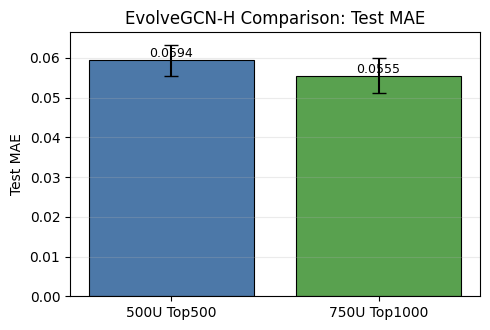

Saved plot to: <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results/test_mae_comparison.png


In [48]:
save_metric_plot(
    summary_df,
    "test_mae_from_predictions",
    OUT_DIR / "test_mae_comparison.png",
)

## 8. Test RMSE Comparison

Test RMSE penalizes larger errors more strongly than MAE. The reported mean RMSE decreases from about `0.0704` for `500U Top500` to about `0.0675` for `750U Top1000`, indicating a modest improvement.

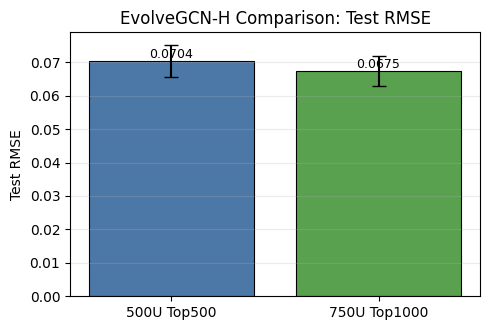

Saved plot to: <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results/test_rmse_comparison.png


In [49]:
save_metric_plot(
    summary_df,
    "test_rmse_from_predictions",
    OUT_DIR / "test_rmse_comparison.png",
)

## 9. Test R² Comparison

Test R² checks whether the model explains target variance better than a simple mean predictor. Even when MAE and RMSE improve, negative R² means the model still does not explain the target range well.

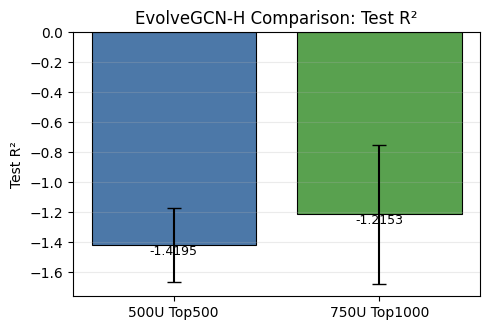

Saved plot to: <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results/test_r2_comparison.png


In [50]:
save_metric_plot(
    summary_df,
    "test_r2_from_predictions",
    OUT_DIR / "test_r2_comparison.png",
)

## 10. Combined Metric Summary Figure

This compact figure places MAE, RMSE, and R² side by side so the improvement in error metrics can be compared against the remaining weakness in explained variance.

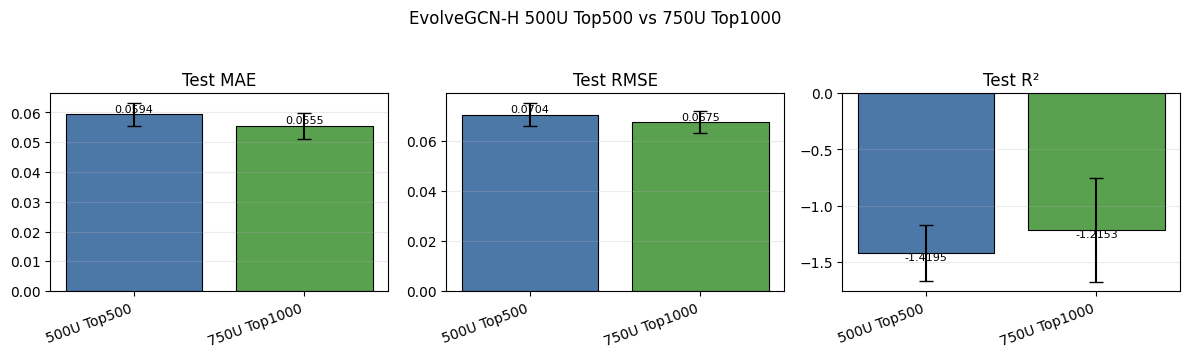

Saved combined metric comparison to: <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results/combined_metric_comparison.png


In [51]:
fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.4))
colors = ["#4C78A8", "#59A14F"]

for ax, metric in zip(axes, METRIC_COLUMNS):
    labels = summary_df["setting"].to_numpy()
    means = summary_df[f"{metric}_mean"].astype(float).to_numpy()
    stds = summary_df[f"{metric}_std"].astype(float).to_numpy()
    x = np.arange(len(labels))

    bars = ax.bar(x, means, yerr=stds, capsize=5, color=colors, edgecolor="black", linewidth=0.8)
    ax.set_title(METRIC_LABELS[metric])
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.grid(axis="y", alpha=0.25)

    for bar, value in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.4f}",
            ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=8,
        )

fig.suptitle("EvolveGCN-H 500U Top500 vs 750U Top1000", y=1.04)
fig.tight_layout()

combined_plot_path = OUT_DIR / "combined_metric_comparison.png"
fig.savefig(combined_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved combined metric comparison to: {combined_plot_path}")

## 11. Prediction Diagnostics

This section compares the seed-42 prediction outputs from the two experiments using the saved `test_predictions.csv` files. The plots mirror the useful diagnostic style from the prior notebook, including sorted target vs prediction curves, true-vs-predicted scatter, residuals versus true `Omega_m`, and the prediction distribution.

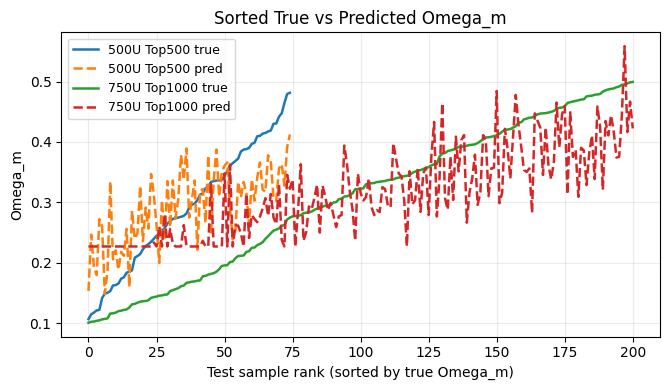

Saved plot to: <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results/prediction_sorted_true_vs_predicted_curve.png


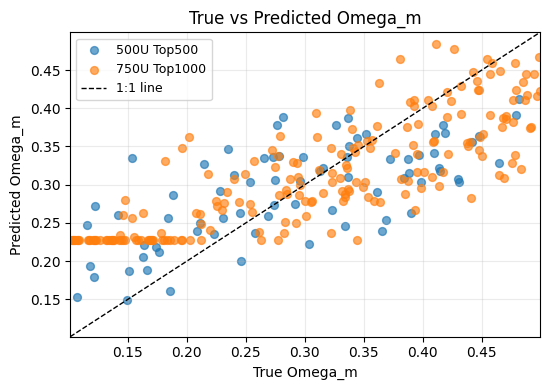

Saved plot to: <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results/prediction_true_vs_predicted_scatter.png


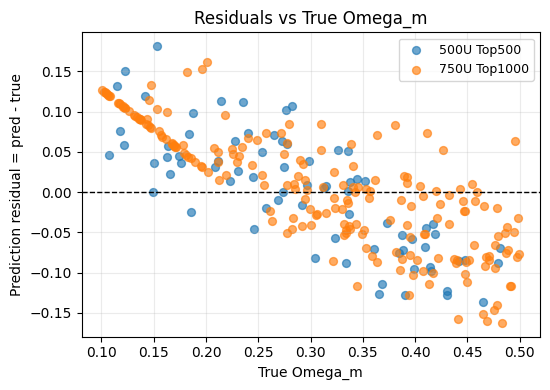

Saved plot to: <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results/prediction_residuals_vs_true_omega_m.png


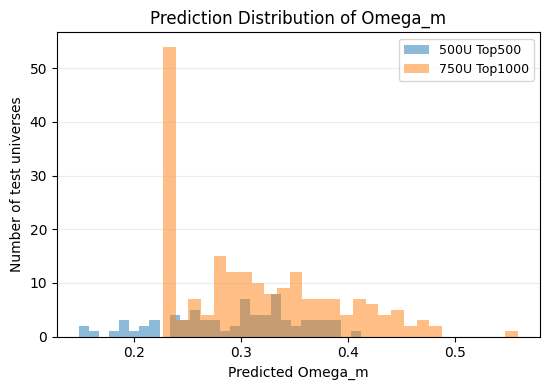

Saved plot to: <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results/prediction_distribution_comparison.png


In [52]:
from pathlib import Path

prediction_inputs = {
    "500U Top500": REPO_ROOT / "experiments" / "evolvegcn_h_500u_top500_h32_seed42_none_norm" / "predictions" / "test_predictions.csv",
    "750U Top1000": REPO_ROOT / "experiments" / "evolvegcn_h_750u_top1000_h32_seed42_none" / "predictions" / "test_predictions.csv",
}

prediction_dfs = {
    label: pd.read_csv(path) for label, path in prediction_inputs.items()
}

for label, df in prediction_dfs.items():
    df["residual"] = df["pred_omega_m"] - df["true_omega_m"]

# Sorted target vs prediction curves
fig, ax = plt.subplots(figsize=(6.8, 4.0))
for label, df in prediction_dfs.items():
    df_sorted = df.sort_values("true_omega_m")
    x = np.arange(len(df_sorted))
    ax.plot(x, df_sorted["true_omega_m"], label=f"{label} true", linewidth=1.8)
    ax.plot(x, df_sorted["pred_omega_m"], linestyle="--", label=f"{label} pred", linewidth=1.8)

ax.set_title("Sorted True vs Predicted Omega_m")
ax.set_xlabel("Test sample rank (sorted by true Omega_m)")
ax.set_ylabel("Omega_m")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.25)
fig.tight_layout()
plot_path = OUT_DIR / "prediction_sorted_true_vs_predicted_curve.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved plot to: {plot_path}")

# True vs predicted scatter
fig, ax = plt.subplots(figsize=(5.6, 4.0))
for label, df in prediction_dfs.items():
    ax.scatter(
        df["true_omega_m"],
        df["pred_omega_m"],
        alpha=0.65,
        s=32,
        label=label,
    )

lims = [
    min(df["true_omega_m"].min() for df in prediction_dfs.values()),
    max(df["true_omega_m"].max() for df in prediction_dfs.values()),
]
ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.0, label="1:1 line")
ax.set_title("True vs Predicted Omega_m")
ax.set_xlabel("True Omega_m")
ax.set_ylabel("Predicted Omega_m")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
ax.set_xlim(lims)
ax.set_ylim(lims)
fig.tight_layout()
plot_path = OUT_DIR / "prediction_true_vs_predicted_scatter.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved plot to: {plot_path}")

# Residuals vs true Omega_m
fig, ax = plt.subplots(figsize=(5.6, 4.0))
for label, df in prediction_dfs.items():
    ax.scatter(
        df["true_omega_m"],
        df["residual"],
        alpha=0.65,
        s=32,
        label=label,
    )

ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
ax.set_title("Residuals vs True Omega_m")
ax.set_xlabel("True Omega_m")
ax.set_ylabel("Prediction residual = pred - true")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
fig.tight_layout()
plot_path = OUT_DIR / "prediction_residuals_vs_true_omega_m.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved plot to: {plot_path}")

# Prediction distribution
fig, ax = plt.subplots(figsize=(5.6, 4.0))
for label, df in prediction_dfs.items():
    ax.hist(
        df["pred_omega_m"],
        bins=28,
        alpha=0.5,
        label=label,
        density=False,
    )

ax.set_title("Prediction Distribution of Omega_m")
ax.set_xlabel("Predicted Omega_m")
ax.set_ylabel("Number of test universes")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plot_path = OUT_DIR / "prediction_distribution_comparison.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved plot to: {plot_path}")

## 12. Graph/Data Diagnostics

This section uses one representative universe from each processed dataset to compare halo mass and graph connectivity statistics. It also shows an XY projection for a representative `750U Top1000` graph.

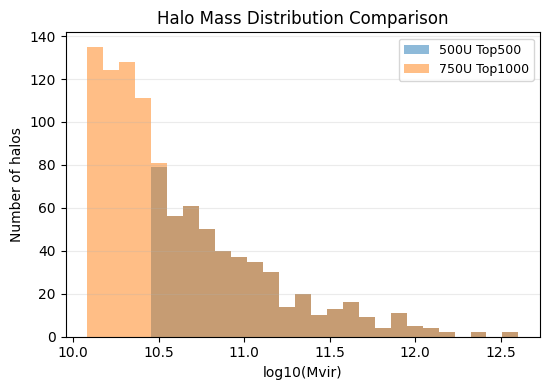

Saved plot to: <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results/halo_mass_distribution_comparison.png


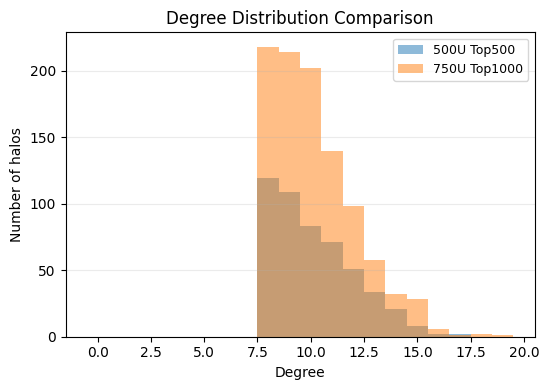

Saved plot to: <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results/halo_degree_distribution_comparison.png


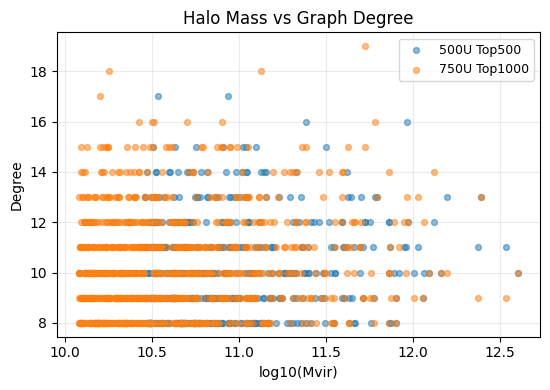

Saved plot to: <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results/halo_mass_vs_degree_comparison.png


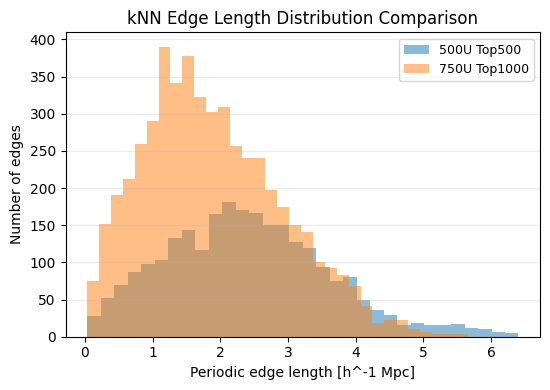

Saved plot to: <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results/knn_edge_length_distribution_comparison.png


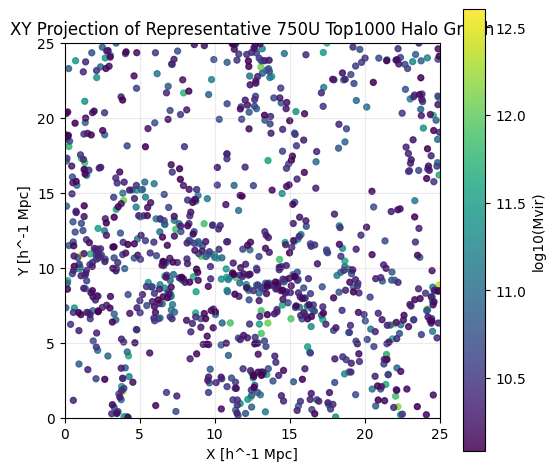

Saved plot to: <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results/xy_projection_750u_top1000.png


In [53]:
import torch

processed_paths = {
    "500U Top500": REPO_ROOT / "data" / "processed" / "temporal_500u_none_top500_periodic_knn" / "camels_500u_temporal_logmass_none_top500_periodic_knn.pt",
    "750U Top1000": REPO_ROOT / "data" / "processed" / "temporal_750u_none_top1000_periodic_knn" / "camels_750u_temporal_logmass_none_top1000_periodic_knn.pt",
}

representative = {}
for label, path in processed_paths.items():
    dataset = torch.load(path, map_location="cpu")
    universe_id = sorted(dataset.keys(), key=lambda x: int(x.split("_")[1]))[0]
    sample = dataset[universe_id]
    del dataset

    snapshot_idx = -1
    A = sample["A_list"][snapshot_idx].cpu().numpy()
    X = sample["Nodes_list"][snapshot_idx].cpu().numpy()
    mask = sample["mask_list"][snapshot_idx].cpu().numpy().reshape(-1)
    if mask.shape[0] == X.shape[0]:
        mask = mask.astype(bool)
        A = A[np.ix_(mask, mask)]
        X = X[mask]
    else:
        mask = np.ones(X.shape[0], dtype=bool)

    if A.shape[0] != X.shape[0]:
        raise ValueError(f"Masked adjacency and feature sizes differ for {label}: {A.shape} vs {X.shape}")

    positions = X[:, 1:4]
    log_mass = X[:, 0]
    adjacency = (A > 0).astype(np.int32)
    degree = adjacency.sum(axis=1)
    box_size = float(sample.get("box_size", 25.0))

    rows, cols = np.where(np.triu(adjacency, k=1) > 0)
    delta = np.abs(positions[rows] - positions[cols])
    delta = np.minimum(delta, box_size - delta)
    edge_lengths = np.sqrt(np.sum(delta ** 2, axis=1))

    representative[label] = {
        "universe_id": universe_id,
        "log_mass": log_mass,
        "positions": positions,
        "degree": degree,
        "edge_lengths": edge_lengths,
        "box_size": box_size,
    }

# Halo mass distribution comparison
fig, ax = plt.subplots(figsize=(5.6, 4.0))
bins = np.linspace(
    min(data["log_mass"].min() for data in representative.values()),
    max(data["log_mass"].max() for data in representative.values()),
    28,
)
for label, data in representative.items():
    ax.hist(data["log_mass"], bins=bins, alpha=0.5, label=label)
ax.set_title("Halo Mass Distribution Comparison")
ax.set_xlabel("log10(Mvir)")
ax.set_ylabel("Number of halos")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plot_path = OUT_DIR / "halo_mass_distribution_comparison.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved plot to: {plot_path}")

# Degree distribution comparison
fig, ax = plt.subplots(figsize=(5.6, 4.0))
max_degree = max(data["degree"].max() for data in representative.values())
bins = np.arange(0, max_degree + 2) - 0.5
for label, data in representative.items():
    ax.hist(data["degree"], bins=bins, alpha=0.5, label=label)
ax.set_title("Degree Distribution Comparison")
ax.set_xlabel("Degree")
ax.set_ylabel("Number of halos")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plot_path = OUT_DIR / "halo_degree_distribution_comparison.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved plot to: {plot_path}")

# Halo mass vs graph degree comparison
fig, ax = plt.subplots(figsize=(5.6, 4.0))
for label, data in representative.items():
    ax.scatter(data["log_mass"], data["degree"], alpha=0.5, s=18, label=label)
ax.set_title("Halo Mass vs Graph Degree")
ax.set_xlabel("log10(Mvir)")
ax.set_ylabel("Degree")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
fig.tight_layout()
plot_path = OUT_DIR / "halo_mass_vs_degree_comparison.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved plot to: {plot_path}")

# kNN edge length distribution comparison
fig, ax = plt.subplots(figsize=(5.6, 4.0))
for label, data in representative.items():
    ax.hist(data["edge_lengths"], bins=32, alpha=0.5, label=label)
ax.set_title("kNN Edge Length Distribution Comparison")
ax.set_xlabel("Periodic edge length [h^-1 Mpc]")
ax.set_ylabel("Number of edges")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plot_path = OUT_DIR / "knn_edge_length_distribution_comparison.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved plot to: {plot_path}")

# XY projection for representative 750U Top1000 sample
sample_750 = representative["750U Top1000"]
fig, ax = plt.subplots(figsize=(5.6, 5.0))
scatter = ax.scatter(
    sample_750["positions"][..., 0],
    sample_750["positions"][..., 1],
    c=sample_750["log_mass"],
    s=18,
    alpha=0.85,
    cmap="viridis",
)
ax.set_title("XY Projection of Representative 750U Top1000 Halo Graph")
ax.set_xlabel("X [h^-1 Mpc]")
ax.set_ylabel("Y [h^-1 Mpc]")
ax.set_xlim(0, sample_750["box_size"])
ax.set_ylim(0, sample_750["box_size"])
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
cbar = fig.colorbar(scatter, ax=ax, label="log10(Mvir)")
fig.tight_layout()
plot_path = OUT_DIR / "xy_projection_750u_top1000.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved plot to: {plot_path}")

## 3D Representative Halo Graph: 750U Top1000

This section visualizes one representative `750U Top1000` graph input from the final snapshot. Nodes are halos, edges are periodic kNN relations, and color encodes halo mass by `log10(Mvir)`. This plot is qualitative, not a model metric, and is intended to verify graph construction and communicate the input representation.

In [54]:
import torch
import numpy as np
from IPython.display import display, IFrame

processed_path = REPO_ROOT / "data" / "processed" / "temporal_750u_none_top1000_periodic_knn" / "camels_750u_temporal_logmass_none_top1000_periodic_knn.pt"

dataset = torch.load(processed_path, map_location="cpu")
selected_key = "LH_0" if "LH_0" in dataset else sorted(dataset.keys(), key=lambda x: int(x.split("_")[1]))[0]
sample = dataset[selected_key]
del dataset

snapshot_idx = -1
A = sample["A_list"][snapshot_idx].cpu().numpy()
X = sample["Nodes_list"][snapshot_idx].cpu().numpy()
mask = sample["mask_list"][snapshot_idx].cpu().numpy().reshape(-1)
if mask.shape[0] == X.shape[0]:
    mask = mask.astype(bool)
    A = A[np.ix_(mask, mask)]
    X = X[mask]

positions = X[:, 1:4]
log_mass = X[:, 0]

edges_available = False
edge_x = []
edge_y = []
edge_z = []
if A is not None and A.ndim == 2 and A.shape[0] == A.shape[1]:
    adj = (A > 0).astype(np.int32)
    rows, cols = np.where(np.triu(adj, k=1) > 0)
    if len(rows) > 0:
        edges_available = True
        max_edges = 500
        if len(rows) > max_edges:
            rng = np.random.default_rng(42)
            chosen = rng.choice(len(rows), size=max_edges, replace=False)
            rows = rows[chosen]
            cols = cols[chosen]
        for i, j in zip(rows, cols):
            edge_x += [positions[i, 0], positions[j, 0], None]
            edge_y += [positions[i, 1], positions[j, 1], None]
            edge_z += [positions[i, 2], positions[j, 2], None]

plotly_html_path = OUT_DIR / "representative_750u_top1000_graph_3d.html"
plotly_png_path = OUT_DIR / "representative_750u_top1000_graph_3d.png"

try:
    import plotly.graph_objects as go

    fig = go.Figure()
    if edges_available:
        fig.add_trace(
            go.Scatter3d(
                x=edge_x,
                y=edge_y,
                z=edge_z,
                mode="lines",
                line=dict(color="rgba(100,100,100,0.35)", width=1),
                name="kNN edges",
            )
        )
    fig.add_trace(
        go.Scatter3d(
            x=positions[:, 0],
            y=positions[:, 1],
            z=positions[:, 2],
            mode="markers",
            marker=dict(
                size=3,
                color=log_mass,
                colorscale="Viridis",
                colorbar=dict(title="log10(Mvir)"),
                opacity=0.8,
            ),
            name="halos",
        )
    )
    fig.update_layout(
        title="Representative 750U Top1000 Halo Graph (final snapshot)",
        scene=dict(
            xaxis_title="X [h^-1 Mpc]",
            yaxis_title="Y [h^-1 Mpc]",
            zaxis_title="Z [h^-1 Mpc]",
            aspectmode="cube",
        ),
        legend=dict(font=dict(size=10)),
        margin=dict(l=0, r=0, t=40, b=0),
    )
    fig.write_html(str(plotly_html_path))
    print(f"Saved interactive plot to: {plotly_html_path}")
    try:
        display(fig)
    except Exception:
        try:
            fig.show()
        except Exception:
            print("Interactive Plotly figure could not be displayed in this notebook environment.")
    try:
        display(IFrame(str(plotly_html_path), width=900, height=600))
    except Exception:
        pass
    try:
        fig.write_image(str(plotly_png_path), scale=2)
        print(f"Saved static PNG to: {plotly_png_path}")
    except Exception as exc:
        print("Could not save static PNG from Plotly; if Kaleido is not installed, use the fallback Matplotlib code path.", exc)
except ImportError as exc:
    print("Plotly is not available; creating a static Matplotlib 3D scatter plot instead.", exc)
    try:
        import matplotlib.pyplot as plt
        from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

        fig = plt.figure(figsize=(6.5, 5.5))
        ax = fig.add_subplot(111, projection="3d")
        if edges_available:
            for i, j in zip(rows, cols):
                ax.plot(
                    [positions[i, 0], positions[j, 0]],
                    [positions[i, 1], positions[j, 1]],
                    [positions[i, 2], positions[j, 2]],
                    color="gray",
                    alpha=0.2,
                    linewidth=0.5,
                )
        p = ax.scatter(
            positions[:, 0],
            positions[:, 1],
            positions[:, 2],
            c=log_mass,
            cmap="viridis",
            s=8,
            alpha=0.8,
        )
        fig.colorbar(p, ax=ax, label="log10(Mvir)")
        ax.set_title("Representative 750U Top1000 Halo Graph (final snapshot)")
        ax.set_xlabel("X [h^-1 Mpc]")
        ax.set_ylabel("Y [h^-1 Mpc]")
        ax.set_zlabel("Z [h^-1 Mpc]")
        fig.tight_layout()
        fig.savefig(str(plotly_png_path), dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved static PNG to: {plotly_png_path}")
    except Exception as exc2:
        print("Could not create a fallback static 3D plot.", exc2)


Saved interactive plot to: <REPO_ROOT>/outputs/evolvegcn_500u_vs_750u_results/representative_750u_top1000_graph_3d.html


Could not save static PNG from Plotly; if Kaleido is not installed, use the fallback Matplotlib code path. 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



## 13. Output Artifacts

This section records the tables and figures generated by the notebook. These artifacts are written under `outputs/evolvegcn_500u_vs_750u_results/` when the notebook is run.

In [ ]:
output_artifacts = pd.DataFrame(
    [
        {"Artifact": "seed_level_results_clean.csv", "Type": "table", "Purpose": "Clean seed-level results with readable setting names"},
        {"Artifact": "group_summary_numeric.csv", "Type": "table", "Purpose": "Numeric mean/std/count summary by setting"},
        {"Artifact": "group_summary_mean_std_table.csv", "Type": "table", "Purpose": "Thesis-facing mean ± std summary table"},
        {"Artifact": "group_summary_reconstructed_from_seed_table.csv", "Type": "table", "Purpose": "Reconstructed summary for reproducibility check"},
        {"Artifact": "test_mae_comparison.png", "Type": "figure", "Purpose": "Mean test MAE comparison"},
        {"Artifact": "test_rmse_comparison.png", "Type": "figure", "Purpose": "Mean test RMSE comparison"},
        {"Artifact": "test_r2_comparison.png", "Type": "figure", "Purpose": "Mean test R² comparison"},
        {"Artifact": "combined_metric_comparison.png", "Type": "figure", "Purpose": "Side-by-side comparison of MAE, RMSE, and R²"},
        {"Artifact": "prediction_sorted_true_vs_predicted_curve.png", "Type": "figure", "Purpose": "Sorted true vs predicted Omega_m curve"},
        {"Artifact": "prediction_true_vs_predicted_scatter.png", "Type": "figure", "Purpose": "True vs predicted Omega_m scatter"},
        {"Artifact": "prediction_residuals_vs_true_omega_m.png", "Type": "figure", "Purpose": "Prediction residuals versus true Omega_m"},
        {"Artifact": "prediction_distribution_comparison.png", "Type": "figure", "Purpose": "Prediction distribution comparison"},
        {"Artifact": "halo_mass_distribution_comparison.png", "Type": "figure", "Purpose": "Halo mass distribution comparison for representative graphs"},
        {"Artifact": "halo_degree_distribution_comparison.png", "Type": "figure", "Purpose": "Degree distribution comparison for representative graphs"},
        {"Artifact": "halo_mass_vs_degree_comparison.png", "Type": "figure", "Purpose": "Halo mass versus graph degree comparison"},
        {"Artifact": "knn_edge_length_distribution_comparison.png", "Type": "figure", "Purpose": "kNN edge length distribution comparison"},
        {"Artifact": "xy_projection_750u_top1000.png", "Type": "figure", "Purpose": "XY projection of a representative 750U Top1000 graph"},
        {"Artifact": "representative_750u_top1000_graph_3d.html", "Type": "figure", "Purpose": "Interactive 3D representative 750U Top1000 graph visualization"},
        {"Artifact": "representative_750u_top1000_graph_3d.png", "Type": "figure", "Purpose": "Static 3D representative 750U Top1000 graph visualization"},
    ]
)


display(output_artifacts)
print(f"Output folder: {OUT_DIR}")

## 12. Thesis Interpretation

The `750U Top1000` EvolveGCN-H experiment shows a modest improvement over the `500U Top500` EvolveGCN-H experiment.

The mean test RMSE decreases from about `0.0704` to about `0.0675`, and the mean test MAE also improves slightly. This suggests that increasing both the number of training universes and the number of selected halos provides useful additional information for the graph model.

However, the mean test R² remains negative. This is important because it means the larger `750U Top1000` experiment still does not explain the target variance well. The model is improving in absolute-error terms, but the improvement is not enough to resolve the broader EvolveGCN-H underperformance or prediction-compression issue.

Therefore, the main scientific interpretation is that increasing data volume and halo count helps somewhat, but it does not fully solve the GNN performance problem. The next controlled architectural experiment should focus on readout and pooling, especially replacing pure mean graph pooling with a richer mean+max graph pooling strategy.